In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
df = pd.read_csv("MotorVehicleCollisions.csv")
df.head()

C:\Users\magnu\AppData\Local\Temp\ipykernel_6712\3258834222.py:5: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("MotorVehicleCollisions.csv")


,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,"40,62179","-73,970024","(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN


# Definition of event:

Scope: Police-reported collisions involving injuries, fatalities, or damage over 


In [87]:
is_kill_bal = df["NUMBER OF PERSONS KILLED"] == df["NUMBER OF MOTORIST KILLED"] + df["NUMBER OF CYCLIST KILLED"] + df["NUMBER OF PEDESTRIANS KILLED"]
len(is_kill_bal[is_kill_bal==False])

113

In [88]:
is_inj_bal = df["NUMBER OF PERSONS INJURED"] == df["NUMBER OF MOTORIST INJURED"] + df["NUMBER OF CYCLIST INJURED"] + df["NUMBER OF PEDESTRIANS INJURED"]
len(is_inj_bal[is_inj_bal==False])

10640

In [31]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2253192
Number of columns: 29


In [32]:
df.shape
df.dtypes
df.duplicated().sum()
df['COLLISION_ID'].duplicated().sum()

0

In [34]:
missing = pd.DataFrame({
    'n_missing': df.isna().sum(),
    'pct_missing': df.isna().mean().mul(100).round(2)
}).sort_values('n_missing', ascending=False)

missing.head(20)

,n_missing,pct_missing
VEHICLE TYPE CODE 5,2243302,99.56
CONTRIBUTING FACTOR VEHICLE 5,2242979,99.55
VEHICLE TYPE CODE 4,2217260,98.41
CONTRIBUTING FACTOR VEHICLE 4,2215899,98.34
VEHICLE TYPE CODE 3,2096532,93.05
CONTRIBUTING FACTOR VEHICLE 3,2090099,92.76
OFF STREET NAME,1851532,82.17
CROSS STREET NAME,862706,38.29
ZIP CODE,687745,30.52
BOROUGH,687462,30.51


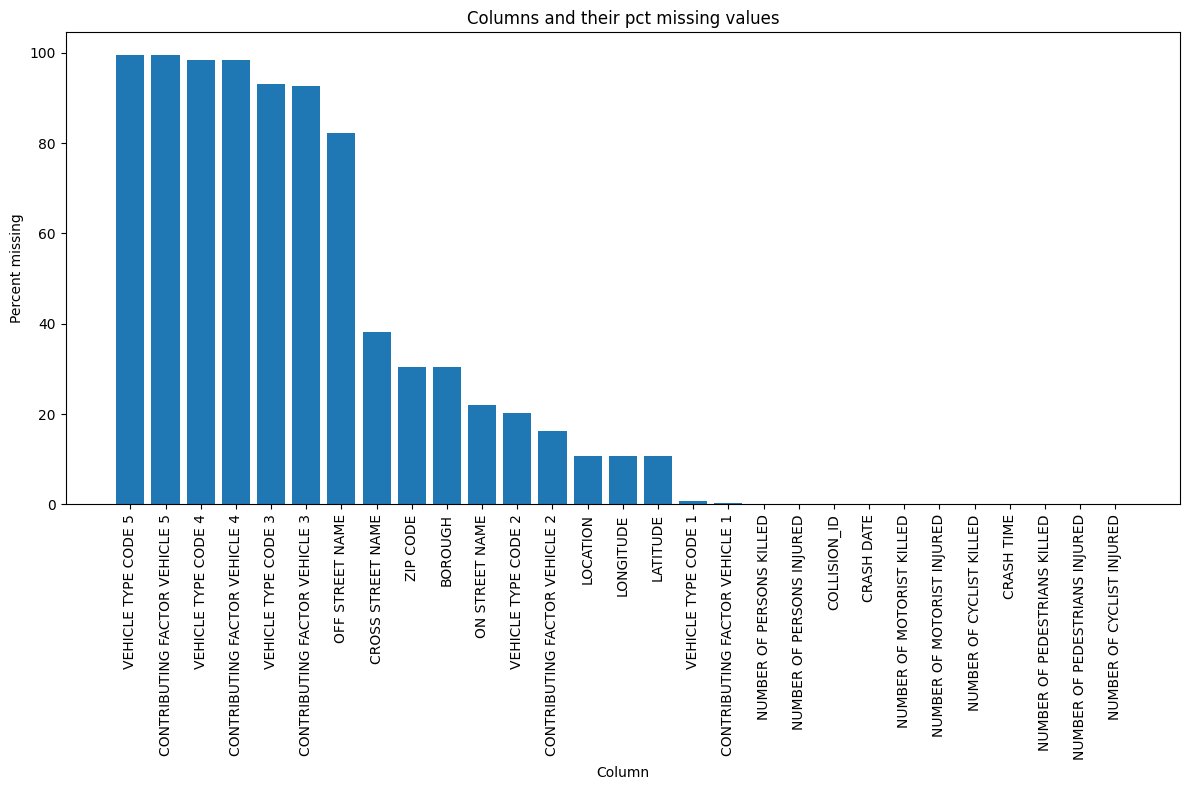

In [35]:
plt.figure(figsize=(12, 8))
plt.bar(missing.index.astype(str), missing["pct_missing"])
plt.xticks(rotation=90)
plt.ylabel("Percent missing")
plt.xlabel("Column")
plt.title("Columns and their pct missing values")
plt.tight_layout()
plt.show()

In [2]:
# parse date/time
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce')

df['CRASH DATETIME'] = (
    df['CRASH DATE'].dt.normalize() +
    pd.to_timedelta(df['CRASH TIME'].dt.hour, unit='h') +
    pd.to_timedelta(df['CRASH TIME'].dt.minute, unit='m')
)
print("Date range:")
print("Start:", df["CRASH DATETIME"].min())
print("End:", df["CRASH DATETIME"].max())

# convert lat/lon if commas are decimal separators
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace(['nan', 'None'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')
    

Date range:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


In [3]:
# Drop rows that dont have spatial or temporal information avaliable.
df_clean =df.dropna(subset=['LATITUDE', 'LONGITUDE','CRASH DATETIME','NUMBER OF PERSONS KILLED','NUMBER OF PERSONS INJURED']).copy()
df_clean.head()
df_clean = df_clean.drop(columns=['CRASH DATE', 'CRASH TIME','LOCATION','VEHICLE TYPE CODE 5','CONTRIBUTING FACTOR VEHICLE 5',
                 'VEHICLE TYPE CODE 4','VEHICLE TYPE CODE 3','CONTRIBUTING FACTOR VEHICLE 4','CONTRIBUTING FACTOR VEHICLE 3',
                 "OFF STREET NAME"])

Notes on data preprocessing:

* Rows represent collision events or incidents. 
* No duplicate rows were found "COLLISION_ID" is unique
* Many missing values are found specifically in columns such as VEHICLE TYPE CODE (X>=3) CONTRIBUTING FACTOR VEHICLE (X>=3) which is most likely due to many collisions not including over 2 contributing factors or vehicles. These are all removed. Further "OFF STREET NAME" is removed since it had high pct missing values. 
* (Maybe all location identifies except LAT/LON?)
* A new column that represent both date and time in datetime format is created. The old two columns are removed
* Latitude and Longitude columns are normalized to be seperated by "."
* Data is cleaned by removing all rows that do not have any spatial or tempral information. It was however seen that no date or time values were missing.
* Also rows where number of person injured/killed are removed since we want to investigate these things. I have decided not to fill these rows since it could possibly inflate the data to represent something that we do not know anything about.

In [38]:
print("Number of rows in cleaned data:", df_clean.shape[0])
print("Number of rows dropped:", df.shape[0]-df_clean.shape[0])
print("Number of columns in cleaned data:", df_clean.shape[1])
print("Number of columns dropped:", df.shape[1]-df_clean.shape[1])
print("Date range in cleaned data:")
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Number of rows in cleaned data: 2012482
Number of rows dropped: 240710
Number of columns in cleaned data: 20
Number of columns dropped: 10
Date range in cleaned data:
Start: 2012-07-01 00:05:00
End: 2026-04-03 23:41:00


To make the data complete, years that are incomplete with data will be dropped. The data start in the middle of 2012 and ends during 2026 hence we will drop these two years:

In [4]:
df_clean = df_clean[~df_clean["CRASH DATETIME"].dt.year.isin([2012, 2026])].copy()
print("Start:", df_clean["CRASH DATETIME"].min())
print("End:", df_clean["CRASH DATETIME"].max())

Start: 2013-01-01 00:01:00
End: 2025-12-31 23:58:00


# When, Where and who are the NYC streets most dangerous for in terms of crashes?

## Distributions

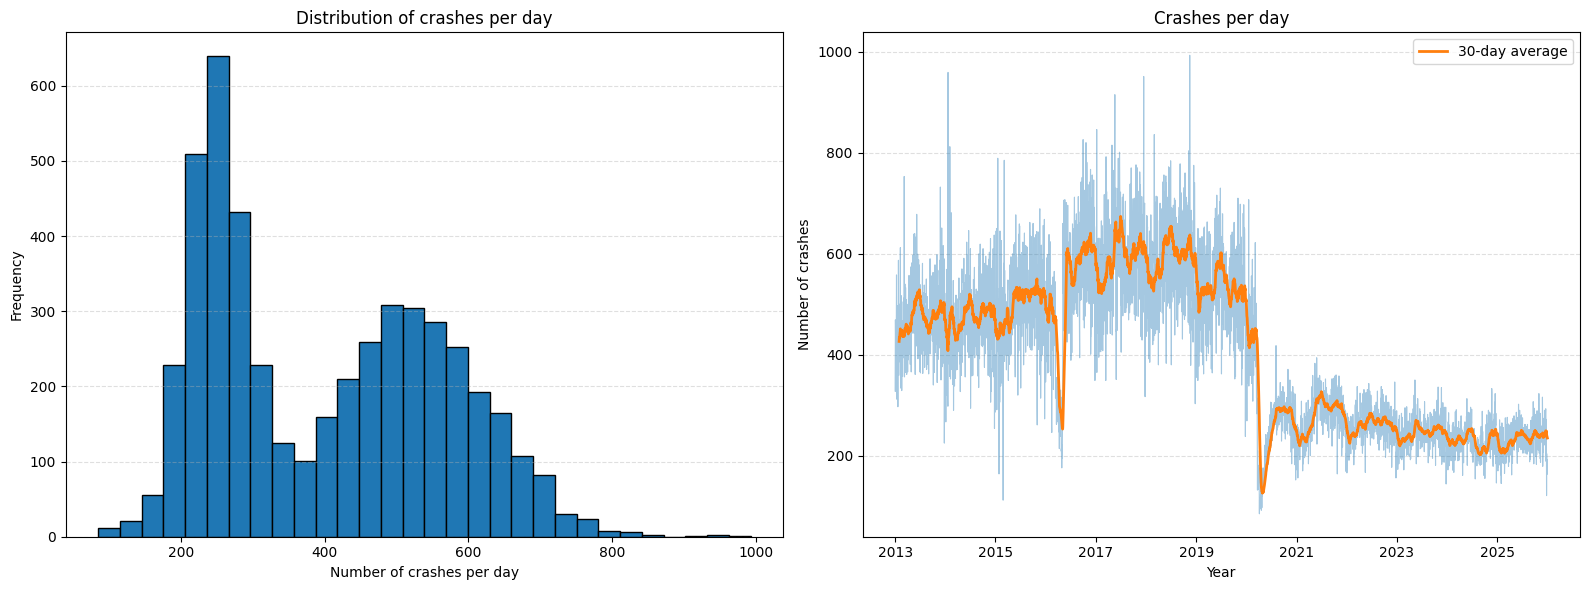

In [ ]:
crashes_per_day = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.date)
      .size()
)

rolling_30 = crashes_per_day.rolling(30).mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(crashes_per_day, bins=30,edgecolor="black")
axes[0].set_xlabel("Number of crashes per day")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of crashes per day")
axes[0].grid(True,axis="y",linestyle="--",alpha=0.4)

axes[1].plot(crashes_per_day.index, crashes_per_day.values, linewidth=0.8, alpha=0.4)
axes[1].plot(rolling_30.index, rolling_30.values, linewidth=2, label="30-day average")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of crashes")
axes[1].set_title("Crashes per day trend")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1].set_axisbelow(True)

tick_years = pd.date_range("2013-01-01", crashes_per_day.index.max(), freq="2YS")
axes[1].set_xticks(tick_years)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].legend()

plt.tight_layout()
plt.show()

Generally we can see that the distribution seems to be bimodal.

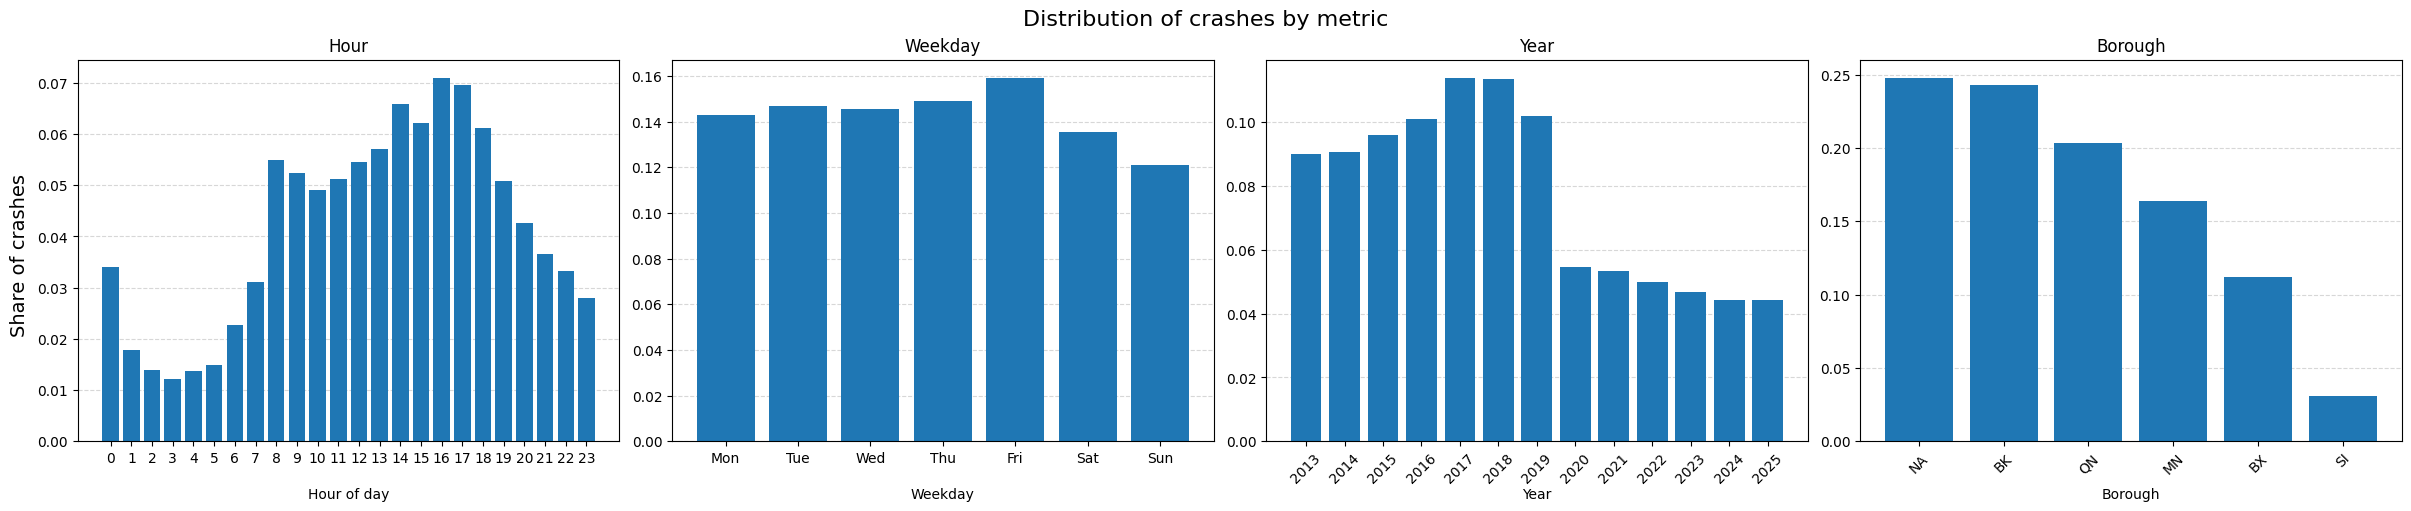

In [ ]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
crashes_by_weekday = (
    df_clean.assign(weekday=df_clean["CRASH DATETIME"].dt.strftime("%a"))
    .groupby("weekday")
    .size()
    .reindex(weekday_order, fill_value=0)
)


crashes_by_hour = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.hour)
    .size()
    .reindex(range(24), fill_value=0)
)


crashes_by_year = (
    df_clean.groupby(df_clean["CRASH DATETIME"].dt.year)
    .size()
    .sort_index()
)


borough_map = {
    "BRONX": "BX",
    "BROOKLYN": "BK",
    "MANHATTAN": "MN",
    "QUEENS": "QN",
    "STATEN ISLAND": "SI",
    "Unknown": "NA"
}

crashes_by_borough = (
    df_clean["BOROUGH"]
      .fillna("Unknown")
      .replace(borough_map)
      .value_counts()
      .reindex(["BX", "BK", "MN", "QN", "SI", "NA"], fill_value=0)
)

crashes_by_hour_share = crashes_by_hour / crashes_by_hour.sum()
crashes_by_weekday_share = crashes_by_weekday / crashes_by_weekday.sum()
crashes_by_year_share = crashes_by_year / crashes_by_year.sum()
crashes_by_borough = crashes_by_borough.sort_values(ascending=False)
crashes_by_borough_share = crashes_by_borough / crashes_by_borough.sum()

fig, axes = plt.subplots(1, 4, figsize=(24, 5), constrained_layout=True)

axes[0].bar(crashes_by_hour.index, crashes_by_hour_share.values)
axes[0].set_title("Hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_xticks(range(24))

axes[1].bar(crashes_by_weekday.index, crashes_by_weekday_share.values)
axes[1].set_title("Weekday")
axes[1].set_xlabel("Weekday")

axes[2].bar(crashes_by_year.index.astype(str), crashes_by_year_share.values)
axes[2].set_title("Year")
axes[2].set_xlabel("Year")
axes[2].tick_params(axis="x", rotation=45)

axes[3].bar(crashes_by_borough.index.astype(str), crashes_by_borough_share.values)
axes[3].set_title("Borough")
axes[3].set_xlabel("Borough")
axes[3].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.xaxis.set_label_coords(0.5, -0.12)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Distribution of crashes by metric", fontsize=16)
fig.supylabel("Share of crashes", fontsize=14)

plt.show()

There is a lower share of crashes during the night hours while most of the crashes occur during 8:00-18:00 where it begins to decrease. This seems to indicate that most incidents occur during the day hours when most people are active on streets. The weekday distribution incidate that Mon-Thu get the same share of crashes while Friday see a slight increase. The weekend seem to a lower share of incidents compared to the weekdays. The yearly distribution shows a slight increase in incidents from 2013-2017. 2018 looks similar in share as 2017 and 2019 is slightly lower. There is a large drop from 2019 to 2020, whereafter a consistent decrease in events happen each year toward 2025. The distribution over Borough indicates that there is a large share of incidents which does not have a documented borough, which was also seen in the preprocessing. Looking further we can see that the Bronx has most crashes. Queens has the second largest, following Manhatten, Brooklyn and lastly Staten Island.

In [13]:
df_clean.columns

Index(['BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'ON STREET NAME',
       'CROSS STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'CRASH DATETIME'],
      dtype='object')

In [5]:
injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# long format for boxplots
injured_long = df_clean[injured_cols].melt(var_name="Metric", value_name="Count").dropna()
killed_long = df_clean[killed_cols].melt(var_name="Metric", value_name="Count").dropna()

# flattened values for histograms
injured_vals = injured_long["Count"]
killed_vals = killed_long["Count"]

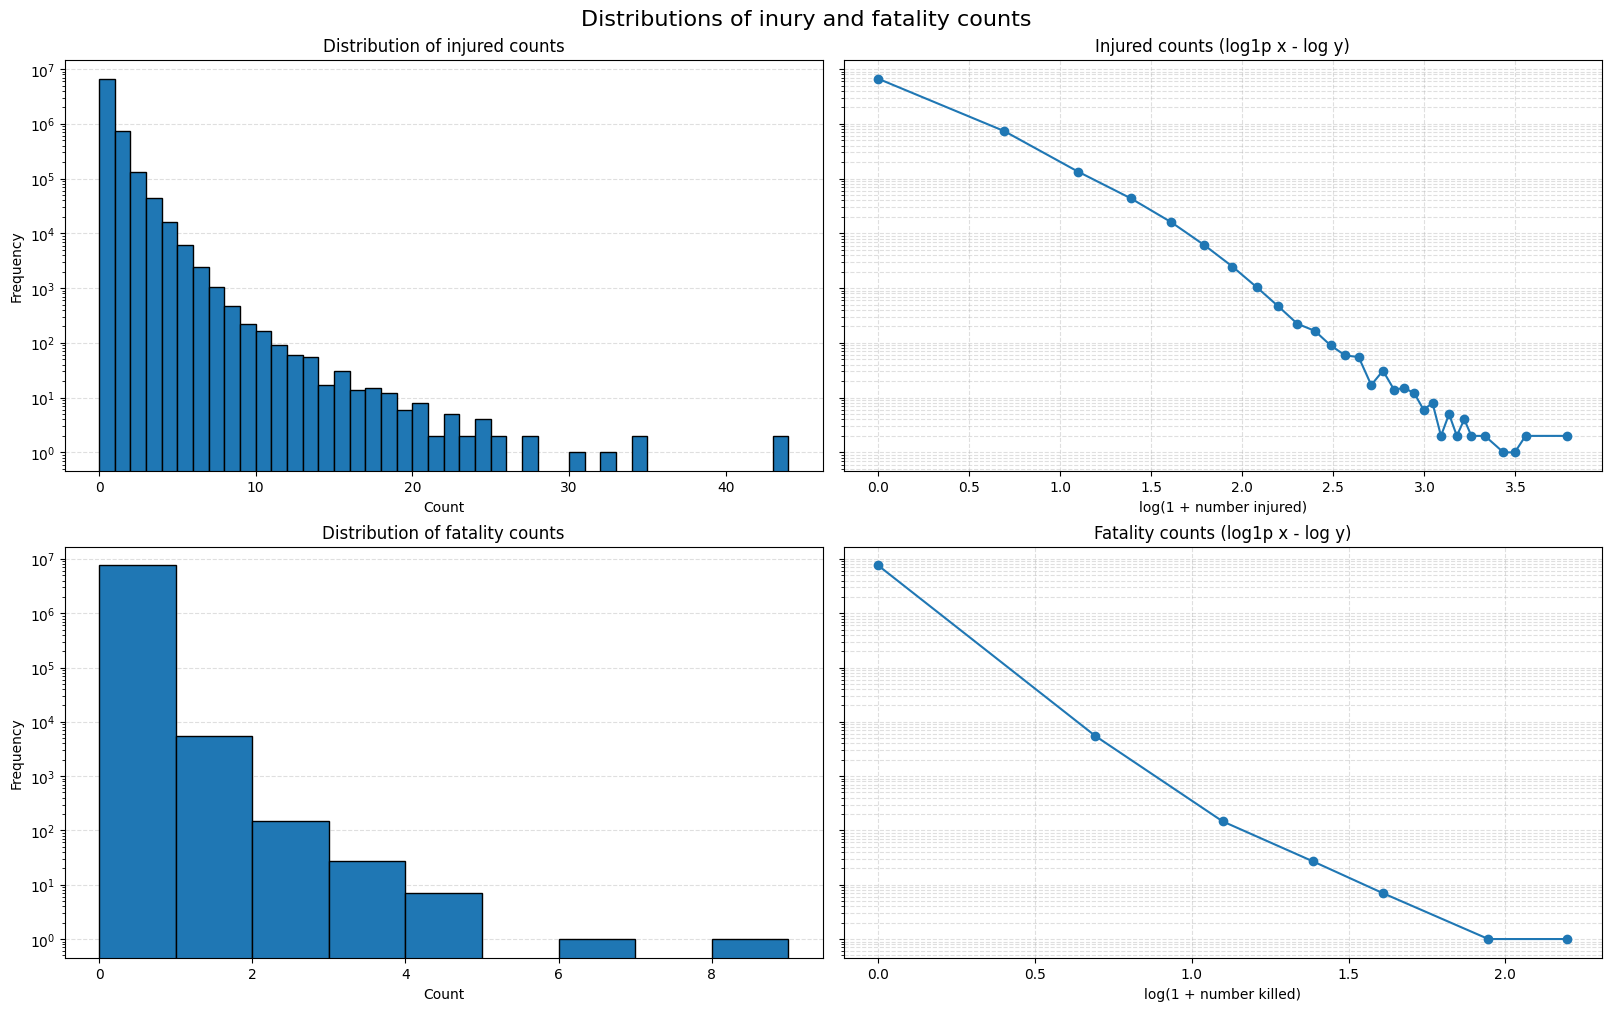

In [35]:
injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# long format for boxplots
injured_long = df_clean[injured_cols].melt(var_name="Metric", value_name="Count").dropna()
killed_long = df_clean[killed_cols].melt(var_name="Metric", value_name="Count").dropna()

# flattened values for histograms
injured_vals = injured_long["Count"]
killed_vals = killed_long["Count"]

injured_freq = injured_vals.value_counts().sort_index()
killed_freq = killed_vals.value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True,sharey='row')
fig.suptitle("Distributions of inury and fatality counts", fontsize=16)
# injured histogram
axes[0, 0].hist(injured_vals, bins=range(0, int(injured_vals.max()) + 2), edgecolor="black")
axes[0, 0].set_title("Distribution of injured counts")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[0, 0].set_axisbelow(True)
axes[0, 0].set_yscale("log")

# injured boxplot
axes[0,1].plot(np.log1p(injured_freq.index), injured_freq.values,marker="o", linestyle="-")
#axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log")
axes[0,1].set_title("Injured counts (log1p x - log y)")
axes[0,1].set_xlabel("log(1 + number injured)")
#axes[0,1].set_ylabel("Frequency")
axes[0,1].grid(True, which="both", linestyle="--", alpha=0.4)

# killed histogram
axes[1, 0].hist(killed_vals, bins=range(0, int(killed_vals.max()) + 2), edgecolor="black")
axes[1, 0].set_title("Distribution of fatality counts")
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, axis="y", linestyle="--", alpha=0.4)
axes[1, 0].set_axisbelow(True)
axes[1, 0].set_yscale("log")

# killed boxplot
axes[1,1].plot(np.log1p(killed_freq.index), killed_freq.values,marker="o", linestyle="-")
#axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log")
axes[1,1].set_title("Fatality counts (log1p x - log y)")
axes[1,1].set_xlabel("log(1 + number killed)")
#axes[1,1].set_ylabel("Frequency")
axes[1,1].grid(True, which="both", linestyle="--", alpha=0.4)

plt.show()

Distributions are dominated by low counts of both injury/fatalities. There is a heavy tail behvaior with power law indicating that most crashes has either no injuries/fatalities or few. There are however some large outliers which gives a heavy tail.

In [83]:
inj_check = (
    df_clean["NUMBER OF PERSONS INJURED"]
    - (
        df_clean["NUMBER OF PEDESTRIANS INJURED"]
        + df_clean["NUMBER OF CYCLIST INJURED"]
        + df_clean["NUMBER OF MOTORIST INJURED"]
    )
)

kil_check = (
    df_clean["NUMBER OF PERSONS KILLED"]
    - (
        df_clean["NUMBER OF PEDESTRIANS KILLED"]
        + df_clean["NUMBER OF CYCLIST KILLED"]
        + df_clean["NUMBER OF MOTORIST KILLED"]
    )
)

print("Injury mismatches:", (inj_check != 0).sum())
print("Killed mismatches:", (kil_check != 0).sum())

Injury mismatches: 9810
Killed mismatches: 72


In [77]:
mask_inj = inj_check != 0
df_clean.loc[
    mask_inj,
    [
        "NUMBER OF PERSONS INJURED",
        "NUMBER OF PEDESTRIANS INJURED",
        "NUMBER OF CYCLIST INJURED",
        "NUMBER OF MOTORIST INJURED",
    ]
].head(20)

,NUMBER OF PERSONS INJURED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF CYCLIST INJURED,NUMBER OF MOTORIST INJURED
42,1.0,0,0,0
58,1.0,0,0,0
295,1.0,0,0,0
367,1.0,0,0,0
396,1.0,0,0,0
420,1.0,0,0,0
432,1.0,0,0,0
574,1.0,0,0,0
915,1.0,0,0,0
1000,1.0,0,0,0


So the number of persons injured is not exactly just the sum of everyone injured? Maybe number of persons include passengers in vehicles for example or something else?

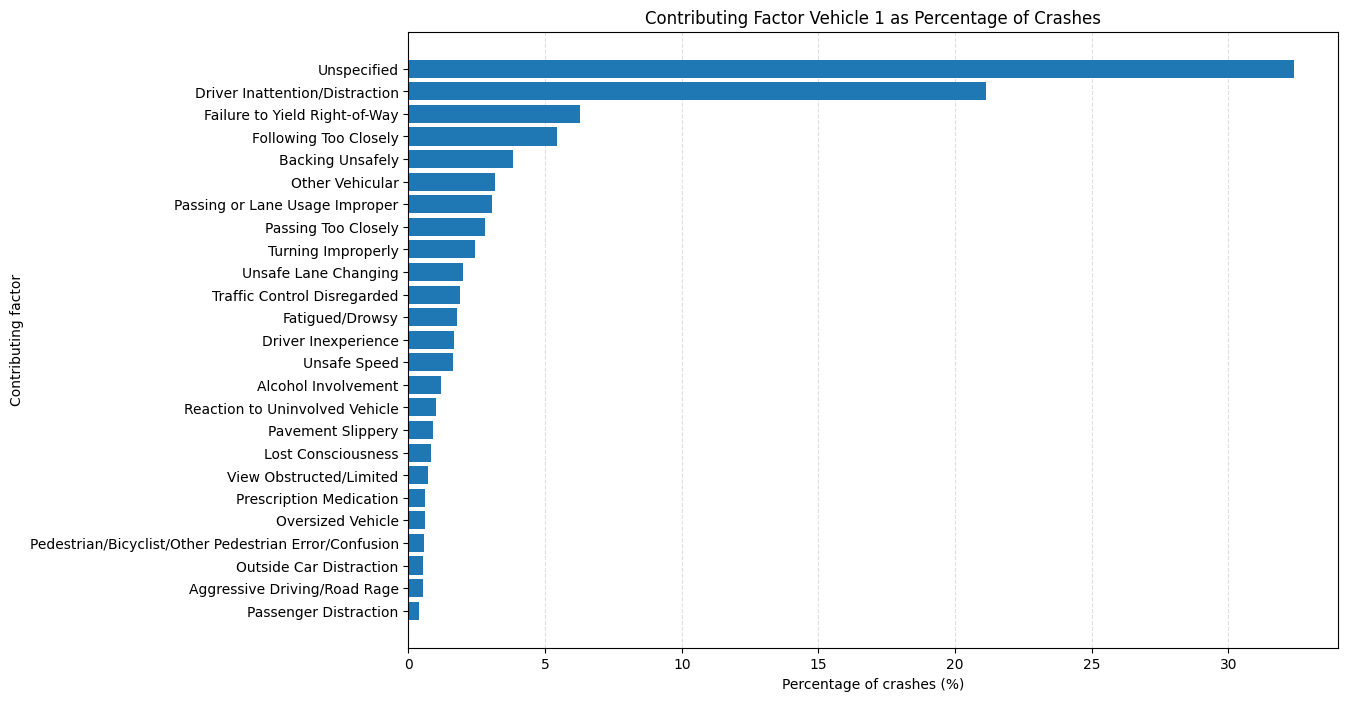

In [82]:
# Fill missing values
df_clean["CONTRIBUTING FACTOR VEHICLE 1"] = (
    df_clean["CONTRIBUTING FACTOR VEHICLE 1"]
    .fillna("Unspecified")
)

# Percentage distribution
factor_pct = (
    df_clean["CONTRIBUTING FACTOR VEHICLE 1"]
    .value_counts(normalize=True)
    .mul(100)
    .head(25)
    .sort_values()
)

# Plot
plt.figure(figsize=(12, 8))
plt.barh(factor_pct.index, factor_pct.values)
plt.xlabel("Percentage of crashes (%)")
plt.ylabel("Contributing factor")
plt.title("Contributing Factor Vehicle 1 as Percentage of Crashes")
plt.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.gca().set_axisbelow(True)
plt.show()

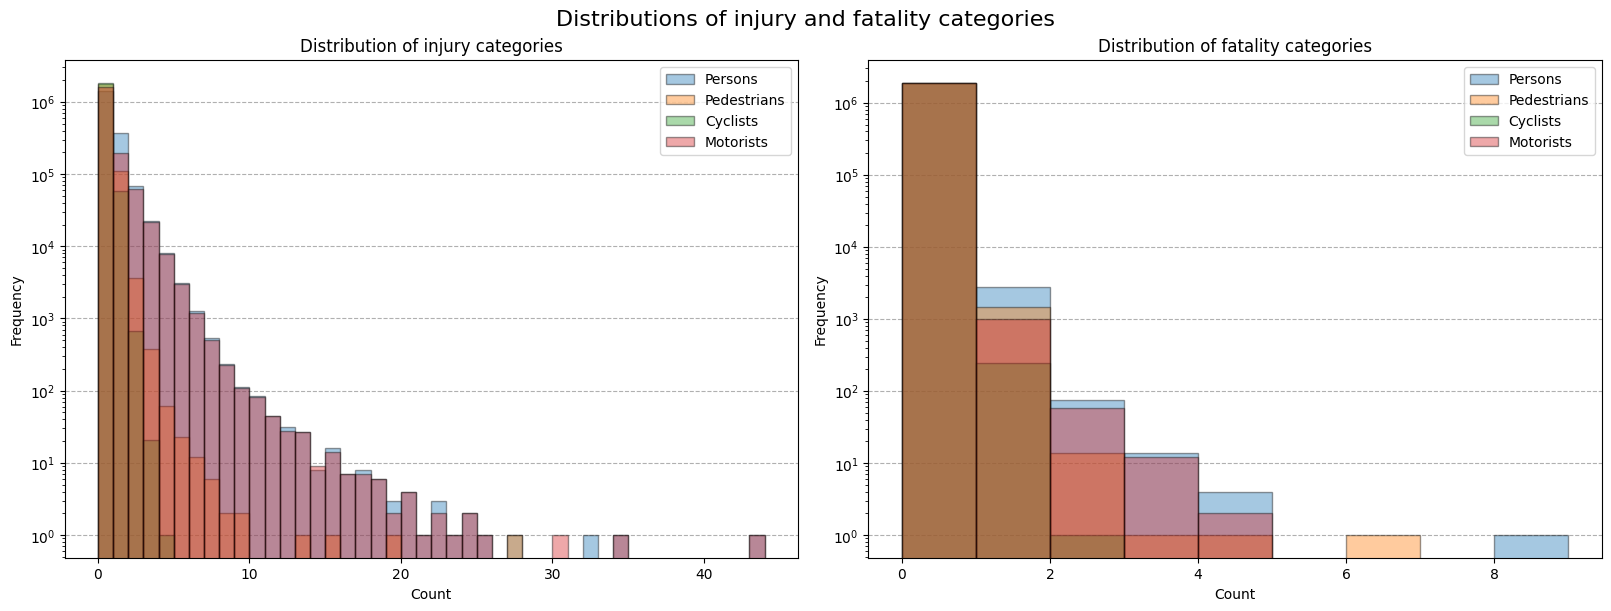

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

# make sure numeric
for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ----- injuries -----
inj_bins = range(
    0,
    int(df_clean[injured_cols].max().max()) + 2
)

for col in injured_cols:
    vals = df_clean[col].dropna()
    axes[0].hist(
        vals,
        bins=inj_bins,
        alpha=0.4,
        label=injury_labels[col],
        edgecolor="black"
    )

axes[0].set_title("Distribution of injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, axis="y", linestyle="--", alpha=1.0)
axes[0].set_axisbelow(True)
axes[0].legend()

# ----- fatalities -----
kill_bins = range(
    0,
    int(df_clean[killed_cols].max().max()) + 2
)

for col in killed_cols:
    vals = df_clean[col].dropna()
    axes[1].hist(
        vals,
        bins=kill_bins,
        alpha=0.4,
        label=fatality_labels[col],
        edgecolor="black"
    )

axes[1].set_title("Distribution of fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, axis="y", linestyle="--", alpha=1.0)
axes[1].set_axisbelow(True)
axes[1].legend()

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)

plt.show()

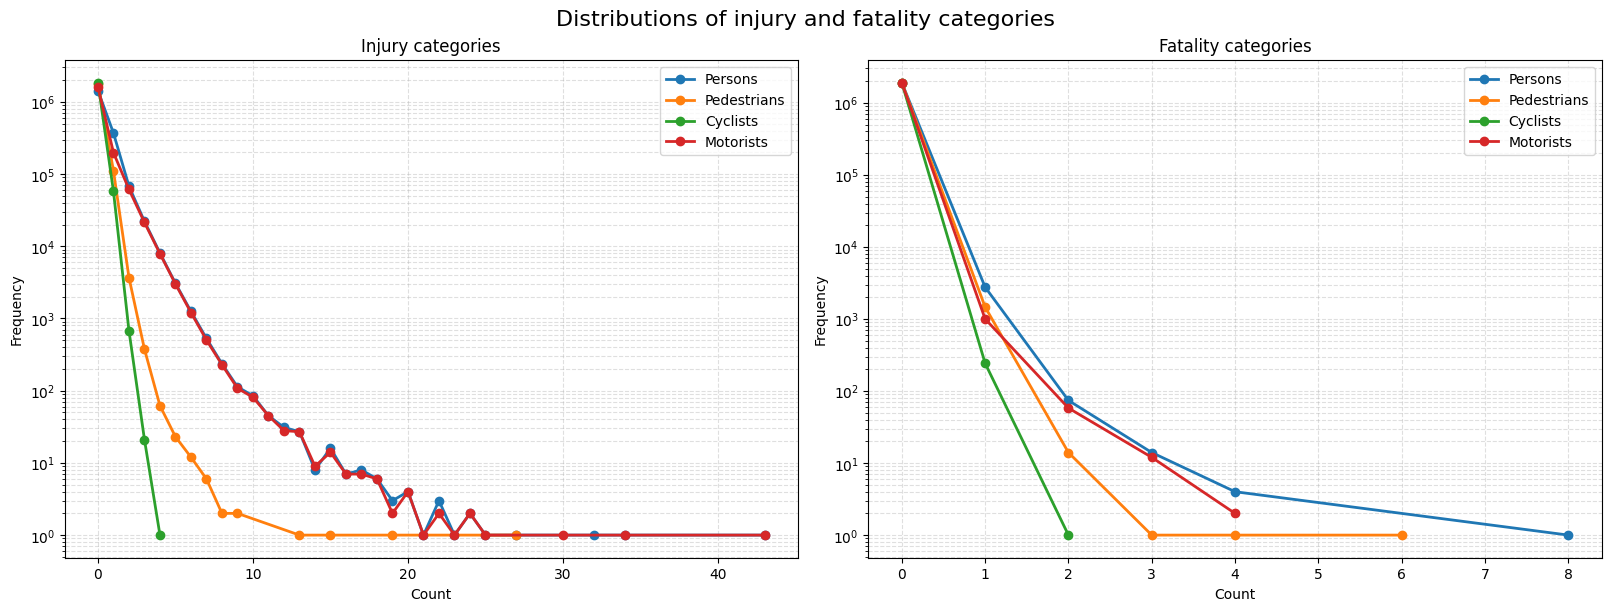

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

labels_inj = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

labels_kil = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# injuries
for col in injured_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[0].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_inj[col])

axes[0].set_title("Injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, which="both", linestyle="--", alpha=0.4)
axes[0].legend()

# fatalities
for col in killed_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[1].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_kil[col])

axes[1].set_title("Fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle="--", alpha=0.4)
axes[1].legend()

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)
plt.show()

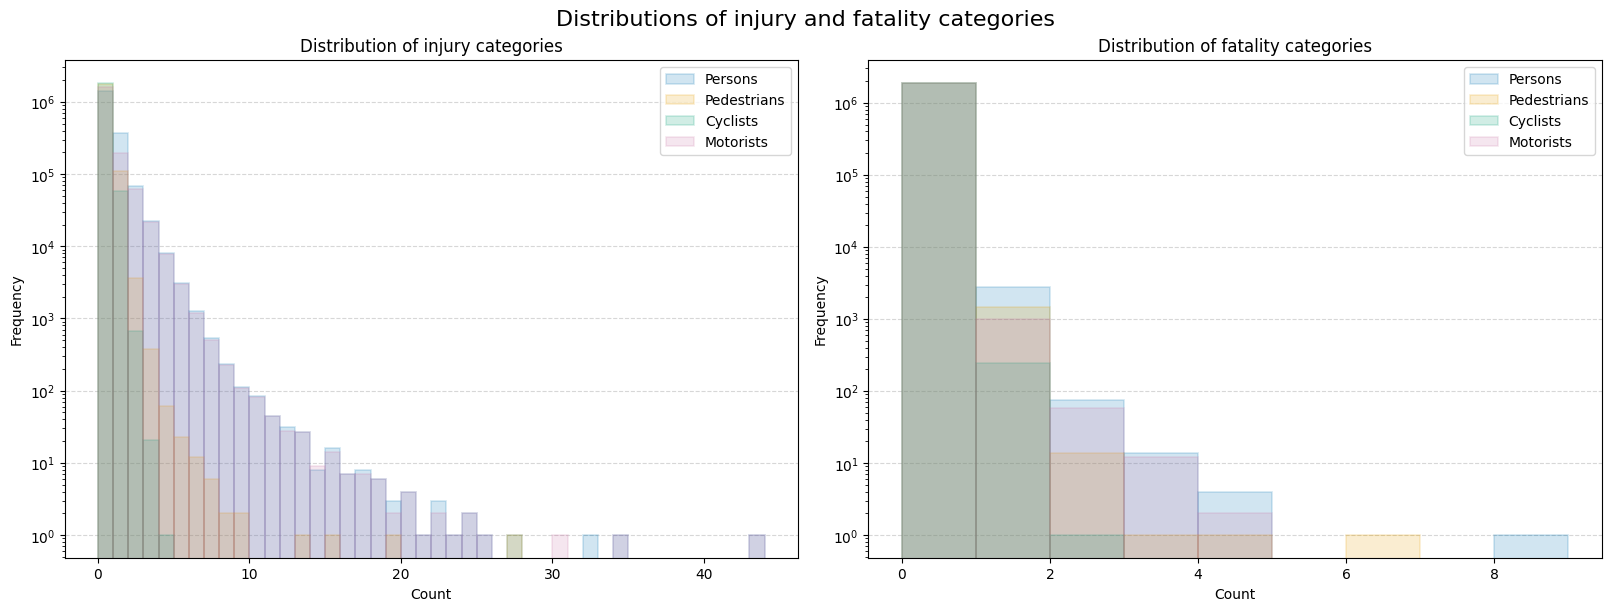

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

injury_labels = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

fatality_labels = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

# Higher-contrast palette than the default tab colors
colors = {
    "Persons": "#0072B2",       # blue
    "Pedestrians": "#E69F00",   # orange
    "Cyclists": "#009E73",      # green
    "Motorists": "#CC79A7",     # magenta
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# ---------- injuries ----------
inj_max = int(df_clean[injured_cols].max().max())
inj_bins = np.arange(0, inj_max + 2)

for col in injured_cols:
    vals = df_clean[col].dropna().astype(int)
    label = injury_labels[col]
    color = colors[label]

    # filled histogram
    counts, bins, _ = axes[0].hist(
        vals,
        bins=inj_bins,
        alpha=0.18,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        label=label
    )

    # frequency polygon on top
    #mids = 0.5 * (bins[:-1] + bins[1:])
    #axes[0].plot(
    #    mids,
    #    counts,
    #    color=color,
    #    linewidth=2.0
    #)

axes[0].set_title("Distribution of injury categories")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[0].set_axisbelow(True)
axes[0].legend(frameon=True)

# ---------- fatalities ----------
kill_max = int(df_clean[killed_cols].max().max())
kill_bins = np.arange(0, kill_max + 2)

for col in killed_cols:
    vals = df_clean[col].dropna().astype(int)
    label = fatality_labels[col]
    color = colors[label]

    counts, bins, _ = axes[1].hist(
        vals,
        bins=kill_bins,
        alpha=0.18,
        color=color,
        edgecolor=color,
        linewidth=1.2,
        label=label
    )

    #mids = 0.5 * (bins[:-1] + bins[1:])
    #axes[1].plot(
    #    mids,
    #    counts,
    #    color=color,
    #    linewidth=2.0
    #)

axes[1].set_title("Distribution of fatality categories")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Frequency")
axes[1].set_yscale("log")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[1].set_axisbelow(True)
axes[1].legend(frameon=True)

fig.suptitle("Distributions of injury and fatality categories", fontsize=16)
plt.show()

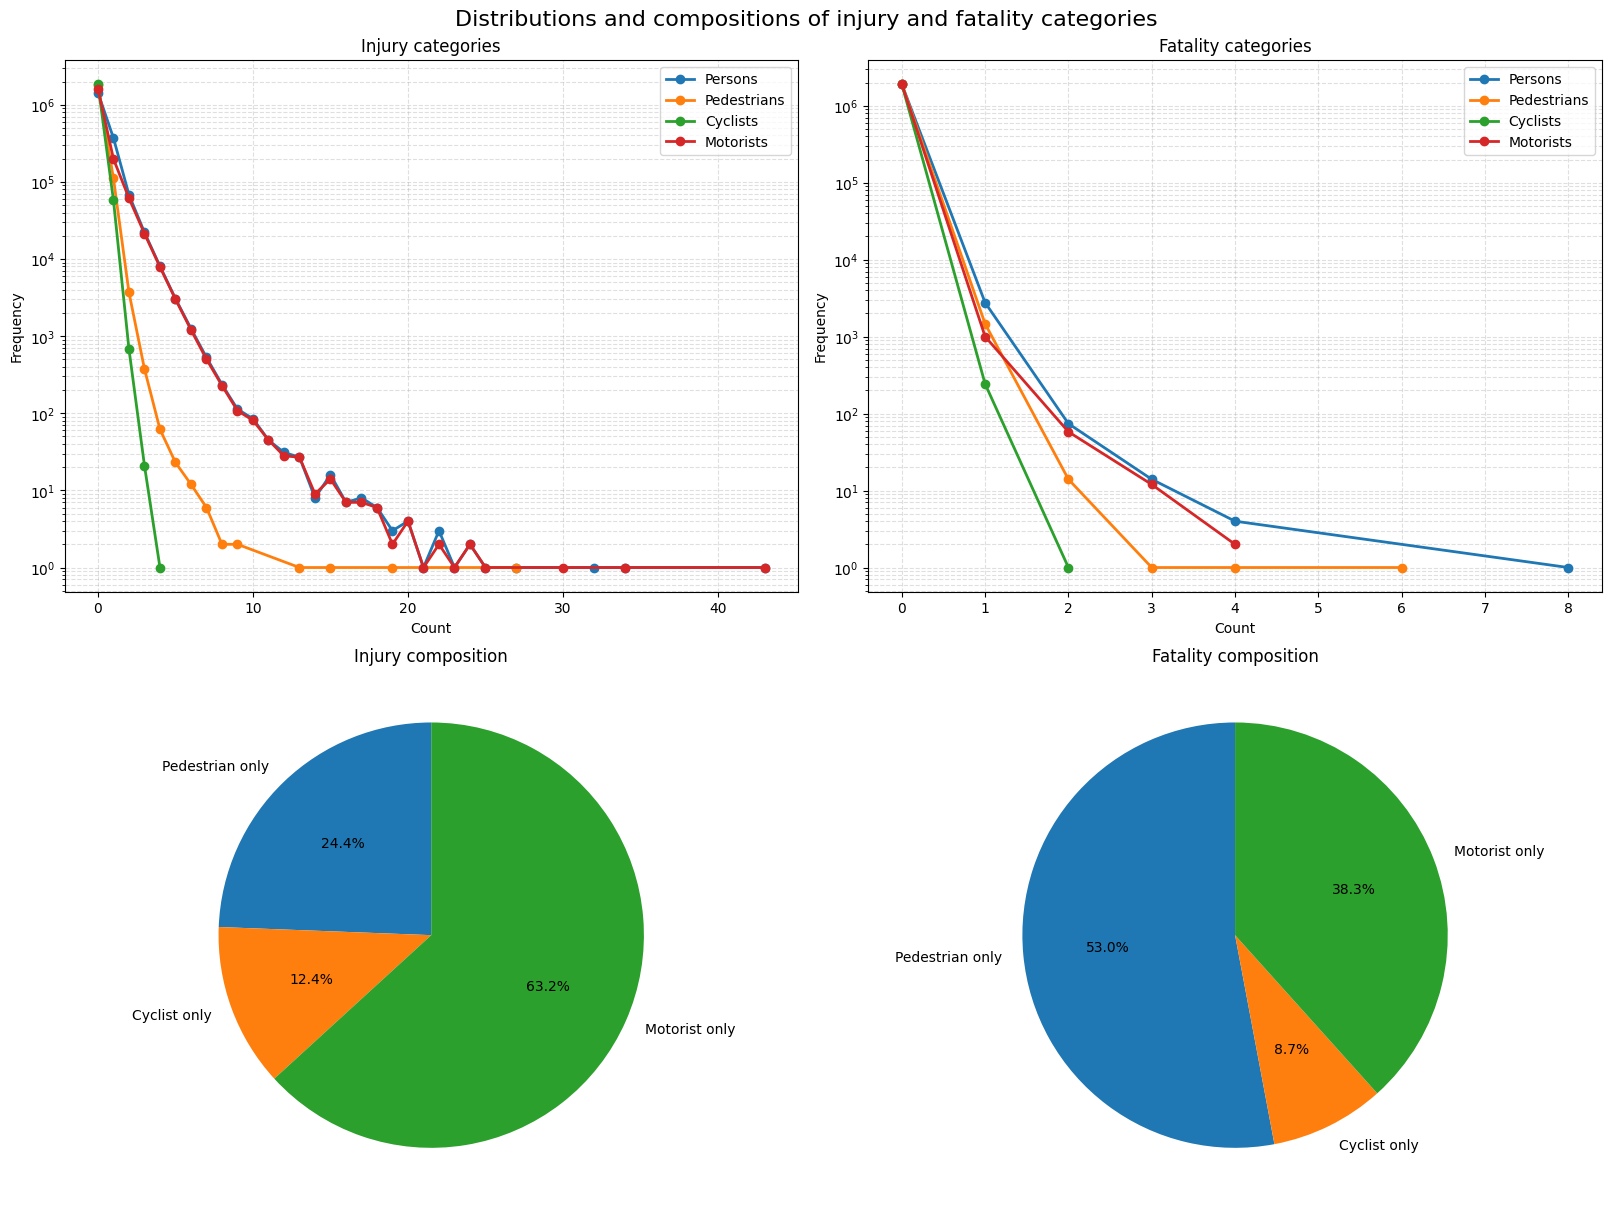

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

injured_cols = [
    "NUMBER OF PERSONS INJURED",
    "NUMBER OF PEDESTRIANS INJURED",
    "NUMBER OF CYCLIST INJURED",
    "NUMBER OF MOTORIST INJURED",
]

killed_cols = [
    "NUMBER OF PERSONS KILLED",
    "NUMBER OF PEDESTRIANS KILLED",
    "NUMBER OF CYCLIST KILLED",
    "NUMBER OF MOTORIST KILLED",
]

labels_inj = {
    "NUMBER OF PERSONS INJURED": "Persons",
    "NUMBER OF PEDESTRIANS INJURED": "Pedestrians",
    "NUMBER OF CYCLIST INJURED": "Cyclists",
    "NUMBER OF MOTORIST INJURED": "Motorists",
}

labels_kil = {
    "NUMBER OF PERSONS KILLED": "Persons",
    "NUMBER OF PEDESTRIANS KILLED": "Pedestrians",
    "NUMBER OF CYCLIST KILLED": "Cyclists",
    "NUMBER OF MOTORIST KILLED": "Motorists",
}

for col in injured_cols + killed_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

# ---------------- top row: line plots ----------------
# injuries
for col in injured_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[0, 0].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_inj[col])

axes[0, 0].set_title("Injury categories")
axes[0, 0].set_xlabel("Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_yscale("log")
axes[0, 0].grid(True, which="both", linestyle="--", alpha=0.4)
axes[0, 0].legend()

# fatalities
for col in killed_cols:
    freq = df_clean[col].dropna().astype(int).value_counts().sort_index()
    axes[0, 1].plot(freq.index, freq.values, marker="o", linewidth=2, label=labels_kil[col])

axes[0, 1].set_title("Fatality categories")
axes[0, 1].set_xlabel("Count")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_yscale("log")
axes[0, 1].grid(True, which="both", linestyle="--", alpha=0.4)
axes[0, 1].legend()

# ---------------- bottom row: pie charts ----------------
# injury pie: mutually exclusive categories
ped_inj = df_clean["NUMBER OF PEDESTRIANS INJURED"].fillna(0) > 0
cyc_inj = df_clean["NUMBER OF CYCLIST INJURED"].fillna(0) > 0
mot_inj = df_clean["NUMBER OF MOTORIST INJURED"].fillna(0) > 0

inj_n_groups = ped_inj.astype(int) + cyc_inj.astype(int) + mot_inj.astype(int)

inj_pie_counts = pd.Series({
    "Pedestrian only": ((ped_inj) & (~cyc_inj) & (~mot_inj)).sum(),
    "Cyclist only": ((~ped_inj) & (cyc_inj) & (~mot_inj)).sum(),
    "Motorist only": ((~ped_inj) & (~cyc_inj) & (mot_inj)).sum(),
})

inj_pie_counts = inj_pie_counts[inj_pie_counts > 0]

axes[1, 0].pie(
    inj_pie_counts.values,
    labels=inj_pie_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 0].set_title("Injury composition")

# fatality pie: mutually exclusive categories
ped_kil = df_clean["NUMBER OF PEDESTRIANS KILLED"].fillna(0) > 0
cyc_kil = df_clean["NUMBER OF CYCLIST KILLED"].fillna(0) > 0
mot_kil = df_clean["NUMBER OF MOTORIST KILLED"].fillna(0) > 0

kil_n_groups = ped_kil.astype(int) + cyc_kil.astype(int) + mot_kil.astype(int)

kil_pie_counts = pd.Series({
    "Pedestrian only": ((ped_kil) & (~cyc_kil) & (~mot_kil)).sum(),
    "Cyclist only": ((~ped_kil) & (cyc_kil) & (~mot_kil)).sum(),
    "Motorist only": ((~ped_kil) & (~cyc_kil) & (mot_kil)).sum(),
})

kil_pie_counts = kil_pie_counts[kil_pie_counts > 0]

axes[1, 1].pie(
    kil_pie_counts.values,
    labels=kil_pie_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1, 1].set_title("Fatality composition")

fig.suptitle("Distributions and compositions of injury and fatality categories", fontsize=16)
plt.show()

## TODO:

Look at temporal information on crashes between the different categories. After that we go heatmaps and maps.

From chat answer it seems that number of person should be the sum so i have to decide if i want to remove it. Medium source to back it up also : https://joycegemcanete.medium.com/simple-analysis-of-the-new-york-motor-vehicle-collision-dataset-c6f883646560